In [9]:
# loading modules

# %load_ext watermark # this is so that in the end we can check which module versions we used
%load_ext autoreload

import warnings 
warnings.filterwarnings("ignore")

import datetime
import glob
import os
import warnings
import dask
import distributed
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xgcm
from matplotlib import ticker, cm
from cartopy import crs as ccrs, feature as cfeature
import cartopy
from pyproj import CRS, Transformer
import xesmf as xe
from skimage import measure


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
cism_grid_path = "/glade/u/home/ifairuz/processed_paleo_data/CISM3_initialization_AIS_08000.LatLon.nc"
cism_init_path = "/glade/u/home/ifairuz/processed_paleo_data/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc"

lgm_ocn_temp_path = "/glade/u/home/ifairuz/processed_paleo_data/LGM/icesm_lgm21ka_atm_PRECIP_monthly_avg_antarctica.nc"
lig_ocn_temp_path = "/glade/u/home/ifairuz/processed_paleo_data/LIG/icesm_lig127ka_atm_PRECIP_monthly_avg_antarctica.nc"


In [11]:
cism_grid_ds = xr.open_dataset(cism_grid_path)
cism_init_ds = xr.open_dataset(cism_init_path)
lgm_ocn_temp_ds = xr.open_dataset(lgm_ocn_temp_path, chunks={"time": 12})
lig_ocn_temp_ds = xr.open_dataset(lig_ocn_temp_path, chunks={"time": 12})

In [12]:
grid_thick = xr.Dataset(
    {
        "lat": (("y1", "x1"), cism_grid_ds["Lat1"].data),
        "lon": (("y1", "x1"), cism_grid_ds["Lon1"].data)
    }
)

lgm_atm_regridder = xe.Regridder(lgm_ocn_temp_ds, grid_thick, method="bilinear", periodic=True)
lig_atm_regridder = xe.Regridder(lig_ocn_temp_ds, grid_thick, method="bilinear", periodic=True)

lgm_atm_regridder.to_netcdf("lgm21ka_to_cism8km_atm_regridder.nc")
lig_atm_regridder.to_netcdf("lig127ka_to_cism8km_atm_regridder.nc")

dropped_lgm_atm = lgm_ocn_temp_ds[["PRECIP"]]
dropped_lig_atm = lig_ocn_temp_ds[["PRECIP"]]

regridded_lgm_atm = lgm_atm_regridder(dropped_lgm_atm)
regridded_lig_atm = lig_atm_regridder(dropped_lig_atm)

regridded_lgm_atm.to_netcdf("lgm21ka_atm_PRECIP_on_cism8km.nc")
regridded_lig_atm.to_netcdf("lig127ka_atm_PRECIP_on_cism8km.nc")

In [15]:
# Subset to just PRECIP before passing to regridder
lgm_precip_only = lgm_ocn_temp_ds[["PRECIP"]]
lig_precip_only = lig_ocn_temp_ds[["PRECIP"]]

lgm_atm_regridder = xe.Regridder(lgm_precip_only, grid_thick, method="bilinear", periodic=True)
lig_atm_regridder = xe.Regridder(lig_precip_only, grid_thick, method="bilinear", periodic=True)

lgm_atm_regridder.to_netcdf("lgm21ka_to_cism8km_atm_precip_regridder.nc")
lig_atm_regridder.to_netcdf("lig127ka_to_cism8km_atm_precip_regridder.nc")

regridded_lgm_atm = lgm_atm_regridder(lgm_precip_only)
regridded_lig_atm = lig_atm_regridder(lig_precip_only)

In [16]:
lon2d = cism_grid_ds["Lon1"].values
lat2d = cism_grid_ds["Lat1"].values

regridded_lgm_atm = regridded_lgm_atm.assign_coords(
    lat=(("y1", "x1"), lat2d),
    lon=(("y1", "x1"), lon2d)
)
regridded_lig_atm = regridded_lig_atm.assign_coords(
    lat=(("y1", "x1"), lat2d),
    lon=(("y1", "x1"), lon2d)
)

regridded_lgm_atm.to_netcdf("lgm21ka_atm_PRECIP_on_cism8km.nc")
regridded_lig_atm.to_netcdf("lig127ka_atm_PRECIP_on_cism8km.nc")

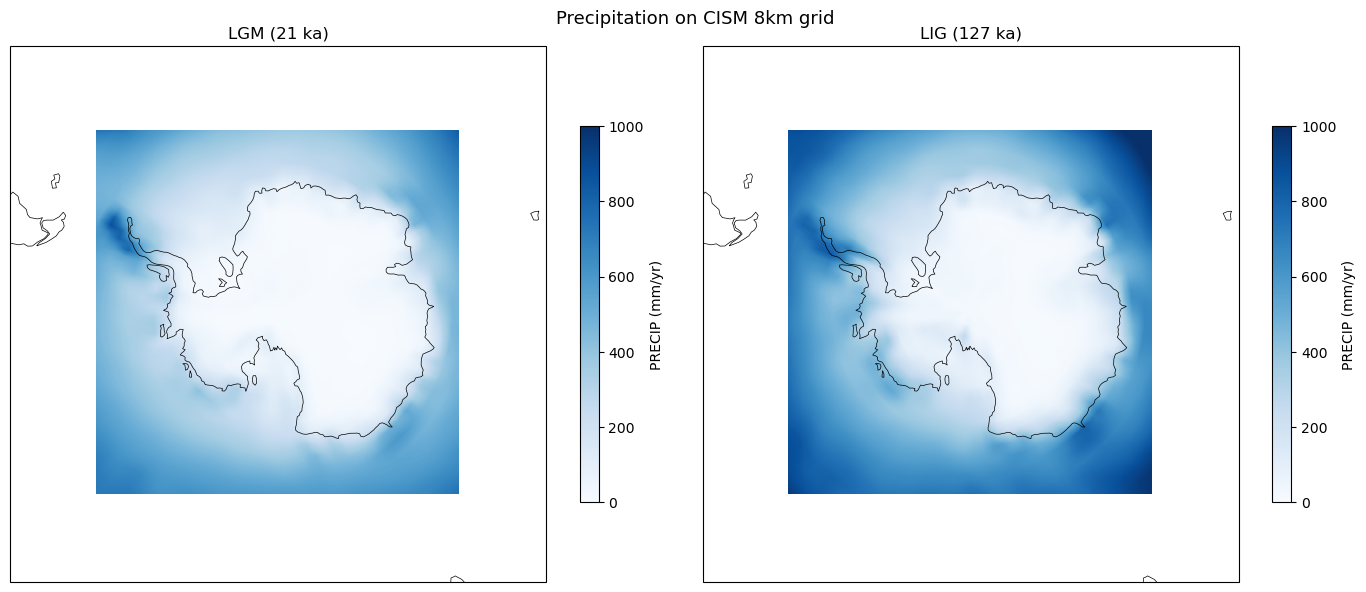

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, ds, title in zip(axes,
                          [regridded_lgm_atm, regridded_lig_atm],
                          ["LGM (21 ka)", "LIG (127 ka)"]):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    field = ds.PRECIP.isel(time=0) * 1000 * 86400 * 365  # m/s to mm/day

    p = ax.pcolormesh(
        ds.lon.values,
        ds.lat.values,
        field.values,
        transform=ccrs.PlateCarree(),
        cmap="Blues",
        vmin=0, vmax=1000
    )
    plt.colorbar(p, ax=ax, label="PRECIP (mm/yr)", shrink=0.7)
    ax.set_title(title)

plt.suptitle("Precipitation on CISM 8km grid", fontsize=13)
plt.tight_layout()
#plt.savefig("LGM_LIG_atm_PRECIP_cism8km.png", dpi=150)
plt.show()